## Step 3 — University Cluster Analysis

This notebook defines four university clusters, identifies Bicing stations within 500m of each, and analyses the temporal and weather-driven behaviour of electric and mechanical bike availability.

| Cluster | Universities | Centroid |
|---------|-------------|----------|
| UB / UPC Nord | UB main + UPC Campus Nord | 41.3888, 2.1147 |
| UB / UPC Sud | UB Les Corts + UPC Campus Sud | 41.3773, 2.1492 |
| UPF Ciutadella | Universitat Pompeu Fabra | 41.3854, 2.1938 |
| URL La Salle | Universitat Ramon Llull / La Salle | 41.4139, 2.1478 |

**Data:** `bikes_20XX_with_weather.csv.gz` (2019, 2021–2024)  
**Depletion definition:** e-bikes == 0 for 2+ consecutive hours between 12:00–20:00

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os, warnings
from math import radians, cos, sin, asin, sqrt
warnings.filterwarnings('ignore')

# ── Palette ────────────────────────────────────────────────────────────────
CLUSTER_COLORS = {
    'UB / UPC Nord'  : '#5B4FBE',
    'UB / UPC Sud'   : '#E8593C',
    'UPF Ciutadella' : '#1D9E75'
}
C_EBIKE = '#5B4FBE'
C_MECH  = '#1D9E75'
C_DEPL  = '#E8593C'
C_GRAY  = '#B4B2A9'
SUMMER  = [7, 8, 9]

plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#f8f8f8',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 11,
})
print('Libraries loaded.')

Libraries loaded.


### 3.1 — Define clusters and identify stations within 500m

In [3]:
CLUSTERS = {
    'UB / UPC Nord'  : {'lat': 41.3888, 'lon': 2.1147},
    'UB / UPC Sud'   : {'lat': 41.3773, 'lon': 2.1492},
    'UPF Ciutadella' : {'lat': 41.3854, 'lon': 2.1938}
}
RADIUS_M = 500

def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon, dlat = lon2 - lon1, lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return 2 * asin(sqrt(a)) * 6371 * 1000

# Get unique station coordinates from 2023 file
coords_df = (
    pd.read_csv('bikes_2023_with_weather.csv.gz', compression='gzip',
                usecols=['station_id', 'latitude', 'longitude'])
    .drop_duplicates('station_id').dropna()
)
print(f'Total unique stations in network: {len(coords_df)}')

# Assign each station to its nearest cluster if within RADIUS_M
# If a station is within range of two clusters, it goes to the closer one
rows = []
for _, st in coords_df.iterrows():
    best_cluster, best_dist = None, float('inf')
    for name, c in CLUSTERS.items():
        d = haversine(c['lon'], c['lat'], st['longitude'], st['latitude'])
        if d <= RADIUS_M and d < best_dist:
            best_cluster, best_dist = name, d
    if best_cluster:
        rows.append({
            'station_id': st['station_id'],
            'cluster'   : best_cluster,
            'dist_m'    : round(best_dist, 1),
            'latitude'  : st['latitude'],
            'longitude' : st['longitude'],
        })

cluster_stations = pd.DataFrame(rows)
cluster_stations.to_csv('cluster_stations.csv', index=False)

print(f'\nStations per cluster (within {RADIUS_M}m):')
for name, grp in cluster_stations.groupby('cluster'):
    print(f'  {name}: {len(grp)} stations')
print(f'\nTotal: {len(cluster_stations)} cluster stations saved to cluster_stations.csv')

Total unique stations in network: 511

Stations per cluster (within 500m):
  UB / UPC Nord: 6 stations
  UB / UPC Sud: 14 stations
  UPF Ciutadella: 10 stations

Total: 30 cluster stations saved to cluster_stations.csv


### 3.2 — Map: cluster stations vs rest of network

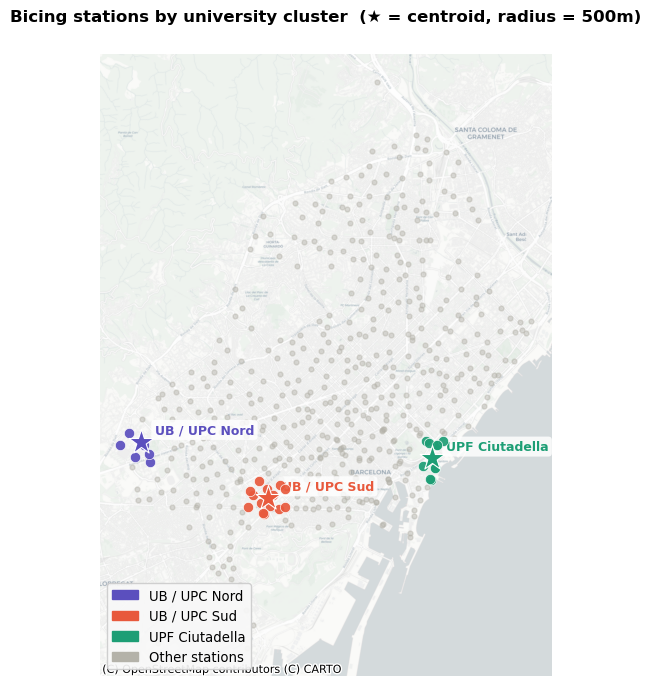

Saved: fig_cluster_map.png


In [8]:
import contextily as ctx
import geopandas as gpd
from shapely.geometry import Point

# ── Convert station coords to GeoDataFrame (WGS84 → Web Mercator) ──────────
# contextily needs Web Mercator (EPSG:3857) to align with tile imagery
def to_gdf(df, lon_col='longitude', lat_col='latitude'):
    geometry = [Point(xy) for xy in zip(df[lon_col], df[lat_col])]
    return gpd.GeoDataFrame(df.copy(), geometry=geometry, crs='EPSG:4326').to_crs('EPSG:3857')

cluster_ids = set(cluster_stations['station_id'])
other_gdf   = to_gdf(coords_df[~coords_df['station_id'].isin(cluster_ids)])
cluster_gdf = to_gdf(cluster_stations)

fig, ax = plt.subplots(figsize=(8, 7))

# Gray background stations
other_gdf.plot(ax=ax, color=C_GRAY, markersize=12, alpha=0.45, zorder=2)

# Cluster stations
for name, grp in cluster_gdf.groupby('cluster'):
    grp_merc = grp  # already projected
    grp_merc.plot(ax=ax, color=CLUSTER_COLORS[name],
                  markersize=55, alpha=0.92,
                  edgecolor='white', linewidth=0.5, zorder=4,
                  label=name)

# Cluster centroid stars
for name, c in CLUSTERS.items():
    pt = gpd.GeoDataFrame(geometry=[Point(c['lon'], c['lat'])],
                          crs='EPSG:4326').to_crs('EPSG:3857')
    ax.scatter(pt.geometry.x, pt.geometry.y,
               marker='*', s=350, c=CLUSTER_COLORS[name],
               edgecolors='white', linewidths=0.8, zorder=6)
    ax.annotate(name,
                xy=(pt.geometry.x.values[0], pt.geometry.y.values[0]),
                xytext=(10, 6), textcoords='offset points',
                fontsize=9, fontweight='bold',
                color=CLUSTER_COLORS[name],
                bbox=dict(boxstyle='round,pad=0.28', fc='white',
                          alpha=0.82, ec='none'))

# ── Add basemap tile ───────────────────────────────────────────────────────
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=14)

# Legend
handles = [mpatches.Patch(color=CLUSTER_COLORS[n], label=n) for n in CLUSTERS]
handles.append(mpatches.Patch(color=C_GRAY, label='Other stations'))
ax.legend(handles=handles, fontsize=9.5, loc='lower left',
          framealpha=0.92, edgecolor='#cccccc')

ax.set_axis_off()
ax.set_title(
    f'Bicing stations by university cluster  (★ = centroid, radius = {RADIUS_M}m)',
    fontsize=12, fontweight='bold', pad=12
)
plt.tight_layout()
plt.savefig('fig_cluster_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_cluster_map.png')

### 3.3 — Load data for cluster stations (all years)

In [47]:
FILES = [
    'bikes_2019_with_weather.csv.gz',
    'bikes_2021_with_weather.csv.gz',
    'bikes_2022_with_weather.csv.gz',
    'bikes_2023_with_weather.csv.gz',
    'bikes_2024_with_weather.csv.gz',
]

COLS = [
    'station_id', 'date',
    'bikes_available', 'mechanical_bikes', 'ebikes', 'docks_available',
    'altitude',
    'temperature_2m', 'precipitation',
    'windspeed_10m', 'is_raining', 'is_windy',
    'weather_category',
]

frames = []
for path in FILES:
    if not os.path.exists(path):
        print(f'  ⚠  Not found: {path} — skipping')
        continue
    avail = pd.read_csv(path, compression='gzip', nrows=0).columns.tolist()
    load  = [c for c in COLS if c in avail]
    df_y  = pd.read_csv(path, compression='gzip', usecols=load)
    df_y  = df_y[df_y['station_id'].isin(cluster_ids)]
    frames.append(df_y)
    print(f'  ✓ {path}: {len(df_y):,} rows')

df = pd.concat(frames, ignore_index=True)

# Standardise column names
df.rename(columns={
    'ebikes'      : 'ebikes',
    'mechanical_bikes' : 'mechanical',
    'bikes_available'                  : 'bikes_total',
    'docks_available'                  : 'docks',
}, inplace=True)

# Time features
df['date']        = pd.to_datetime(df['date'])
df['hour']        = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek
df['month']       = df['date'].dt.month
df['year']        = df['date'].dt.year
df['is_weekend']  = df['day_of_week'].isin([5, 6])
df['date_only']   = df['date'].dt.normalize()
df['capacity']    = (df['bikes_total'] + df['docks']).clip(lower=1)
df['is_hot']      = df['temperature_2m'] > 25

# Normalised availability
df['ebike_NAB'] = df['ebikes']     / df['capacity']
df['mech_NAB']  = df['mechanical'] / df['capacity']

# Attach cluster name
df = df.merge(cluster_stations[['station_id', 'cluster']],
              on='station_id', how='left')

print(f'\nLoaded {len(df):,} rows across {df["station_id"].nunique()} stations')
print(f'Date range: {df["date"].min().date()} → {df["date"].max().date()}')

  ✓ bikes_2019_with_weather.csv.gz: 154,634 rows
  ✓ bikes_2021_with_weather.csv.gz: 259,968 rows
  ✓ bikes_2022_with_weather.csv.gz: 254,073 rows
  ✓ bikes_2023_with_weather.csv.gz: 235,441 rows
  ✓ bikes_2024_with_weather.csv.gz: 64,425 rows

Loaded 968,541 rows across 30 stations
Date range: 2019-03-28 → 2024-03-31


### 3.4 — Compute e-bike depletion events

A day is a **depletion day** for a station if `ebikes == 0` for 2 or more consecutive hours between 12:00 and 20:00.  
This flag is joined back onto the hourly data so every plot can show depletion frequency alongside availability.

In [38]:
def consecutive_zeros(series, n=2):
    """Returns 1 if series contains n or more consecutive 0 values."""
    count = 0
    for v in series:
        count = count + 1 if v == 0 else 0
        if count >= n:
            return 1
    return 0

# Apply only to peak window rows
peak = (
    df[df['hour'].between(12, 20)]
    .sort_values(['station_id', 'date'])
)

depletion = (
    peak.groupby(['station_id', 'date_only', 'cluster'])['ebikes']
    .apply(consecutive_zeros)
    .rename('depleted')
    .reset_index()
)
depletion['date_only'] = pd.to_datetime(depletion['date_only'])

# Join back onto full hourly data
df = df.merge(
    depletion[['station_id', 'date_only', 'depleted']],
    on=['station_id', 'date_only'], how='left'
)
df['depleted'] = df['depleted'].fillna(0).astype(int)

print('Depletion rate by cluster (term-time weekdays):')
term_wd = df[~df['is_weekend'] & ~df['month'].isin(SUMMER)]
for name, grp in term_wd.groupby('cluster'):
    # One depletion rate per unique station-day
    rate = (
        grp.groupby(['station_id', 'date_only'])['depleted']
        .first().mean()
    )
    print(f'  {name}: {rate:.1%}')

Depletion rate by cluster (term-time weekdays):
  UB / UPC Nord: 72.2%
  UB / UPC Sud: 67.1%
  UPF Ciutadella: 92.3%


### 3.5 — Temporal analysis

All plots use **term-time weekdays only** (excluding July–September and weekends) unless noted.  
Each panel shows electric bike NAB (purple), mechanical NAB (teal), and depletion frequency (coral bars on a secondary axis).

In [39]:
# ── Helper: dual-axis plot (NAB lines + depletion bars) ────────────────────
def plot_availability_depletion(ax, x, ebike_vals, mech_vals, depl_vals,
                                 xlabel='', title='', xtick_labels=None):
    ax2 = ax.twinx()

    # Depletion bars on secondary axis (behind lines)
    ax2.bar(x, depl_vals, color=C_DEPL, alpha=0.25, width=0.6, zorder=1)
    ax2.set_ylabel('Depletion frequency', color=C_DEPL, fontsize=9)
    ax2.tick_params(axis='y', labelcolor=C_DEPL, labelsize=8)
    ax2.set_ylim(0, max(depl_vals) * 3 if max(depl_vals) > 0 else 1)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))

    # NAB lines on primary axis
    ax.plot(x, ebike_vals, color=C_EBIKE, lw=2.2,
            marker='o', ms=3.5, label='E-bike NAB', zorder=3)
    ax.plot(x, mech_vals,  color=C_MECH,  lw=2.2,
            marker='s', ms=3.5, label='Mechanical NAB', zorder=3)

    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel('Avg availability (% capacity)', fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
    ax.grid(True, alpha=0.25, linestyle='--', zorder=0)
    ax.spines['top'].set_visible(False)

    if xtick_labels is not None:
        ax.set_xticks(x)
        ax.set_xticklabels(xtick_labels, fontsize=8)

    return ax, ax2


term_wd = df[~df['is_weekend'] & ~df['month'].isin(SUMMER)].copy()
CLUSTER_NAMES = list(CLUSTERS.keys())

print('Helper and filtered slice ready.')

Helper and filtered slice ready.


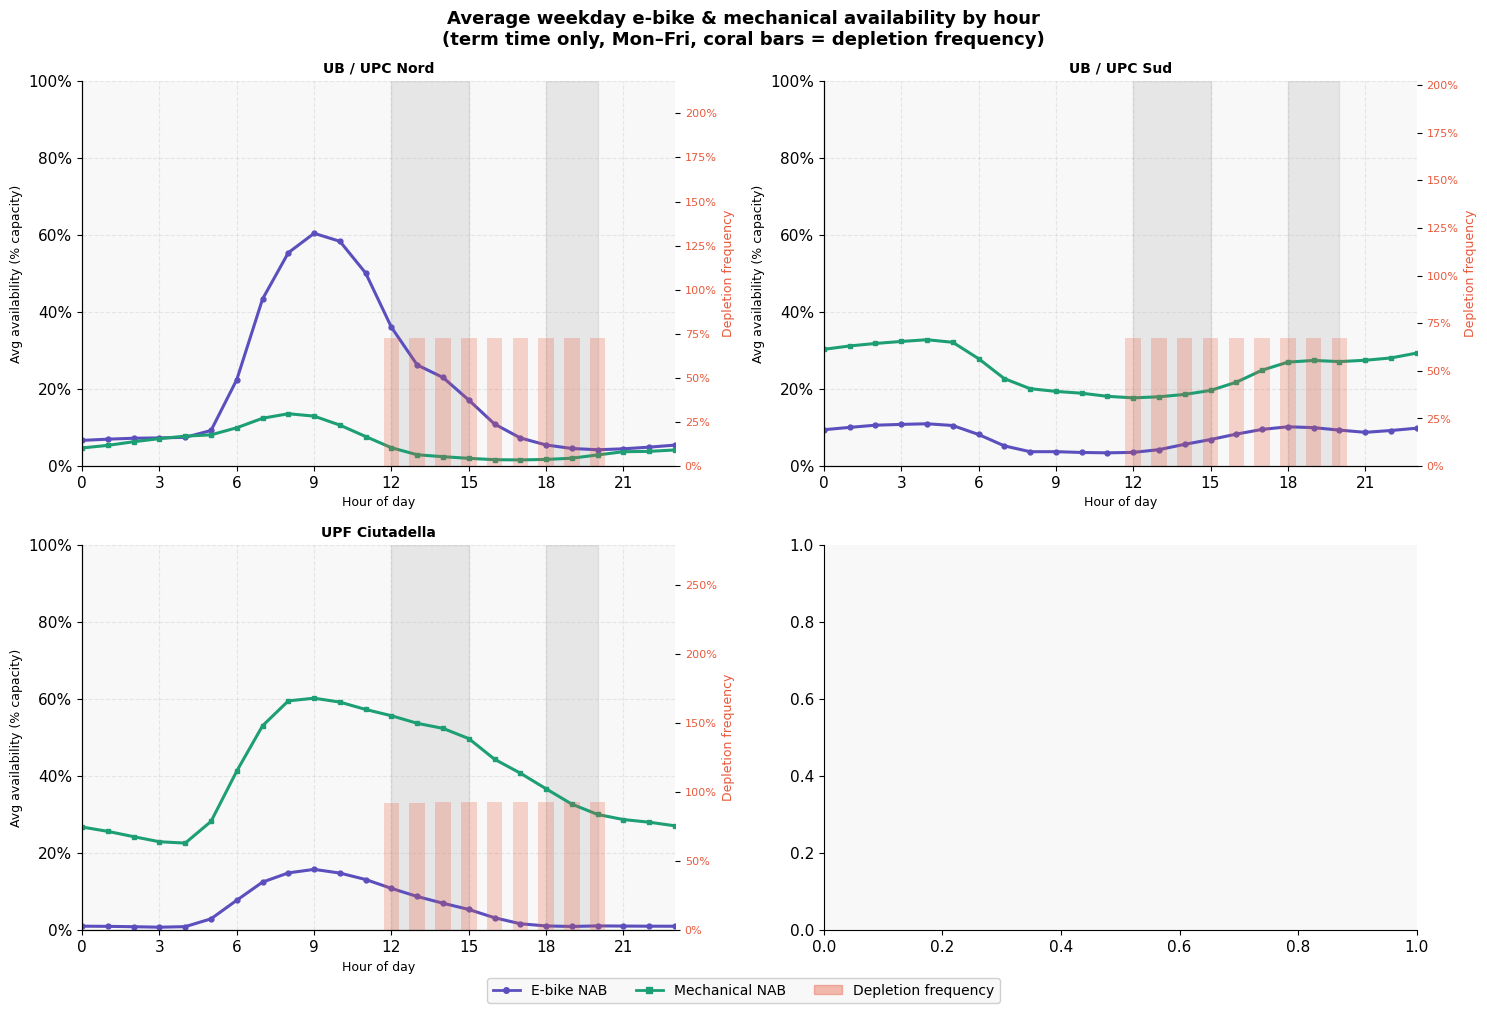

Saved: fig_temporal_hourly.png


In [46]:
# ── Plot A: Average weekday profile by hour ────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(
    'Average weekday e-bike & mechanical availability by hour\n'
    '(term time only, Mon–Fri, coral bars = depletion frequency)',
    fontsize=13, fontweight='bold'
)

for ax, name in zip(axes.flat, CLUSTER_NAMES):
    grp = term_wd[term_wd['cluster'] == name]

    hourly = grp.groupby('hour').agg(
        ebike_NAB=('ebike_NAB', 'mean'),
        mech_NAB =('mech_NAB',  'mean'),
    ).reset_index()

    # Depletion frequency: fraction of station-days depleted, averaged by hour
    depl_by_hour = (
        grp[grp['hour'].between(12, 20)]
        .groupby(['station_id', 'date_only', 'hour'])['depleted']
        .first()
        .groupby('hour').mean()
        .reindex(range(24), fill_value=0)
    )

    plot_availability_depletion(
        ax,
        x           = hourly['hour'],
        ebike_vals  = hourly['ebike_NAB'],
        mech_vals   = hourly['mech_NAB'],
        depl_vals   = depl_by_hour.values,
        xlabel      = 'Hour of day',
        title       = name,
    )
    ax.set_xticks(range(0, 24, 3))
    ax.set_xlim(0, 23)
    ax.axvspan(12, 15, alpha=0.07, color='black')
    ax.axvspan(18, 20, alpha=0.07, color='black')

# Shared legend
handles = [
    plt.Line2D([0],[0], color=C_EBIKE, lw=2, marker='o', ms=4, label='E-bike NAB'),
    plt.Line2D([0],[0], color=C_MECH,  lw=2, marker='s', ms=4, label='Mechanical NAB'),
    mpatches.Patch(color=C_DEPL, alpha=0.4, label='Depletion frequency'),
]
fig.legend(handles=handles, loc='lower center', ncol=3,
           fontsize=10, framealpha=0.9, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig('fig_temporal_hourly.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_temporal_hourly.png')

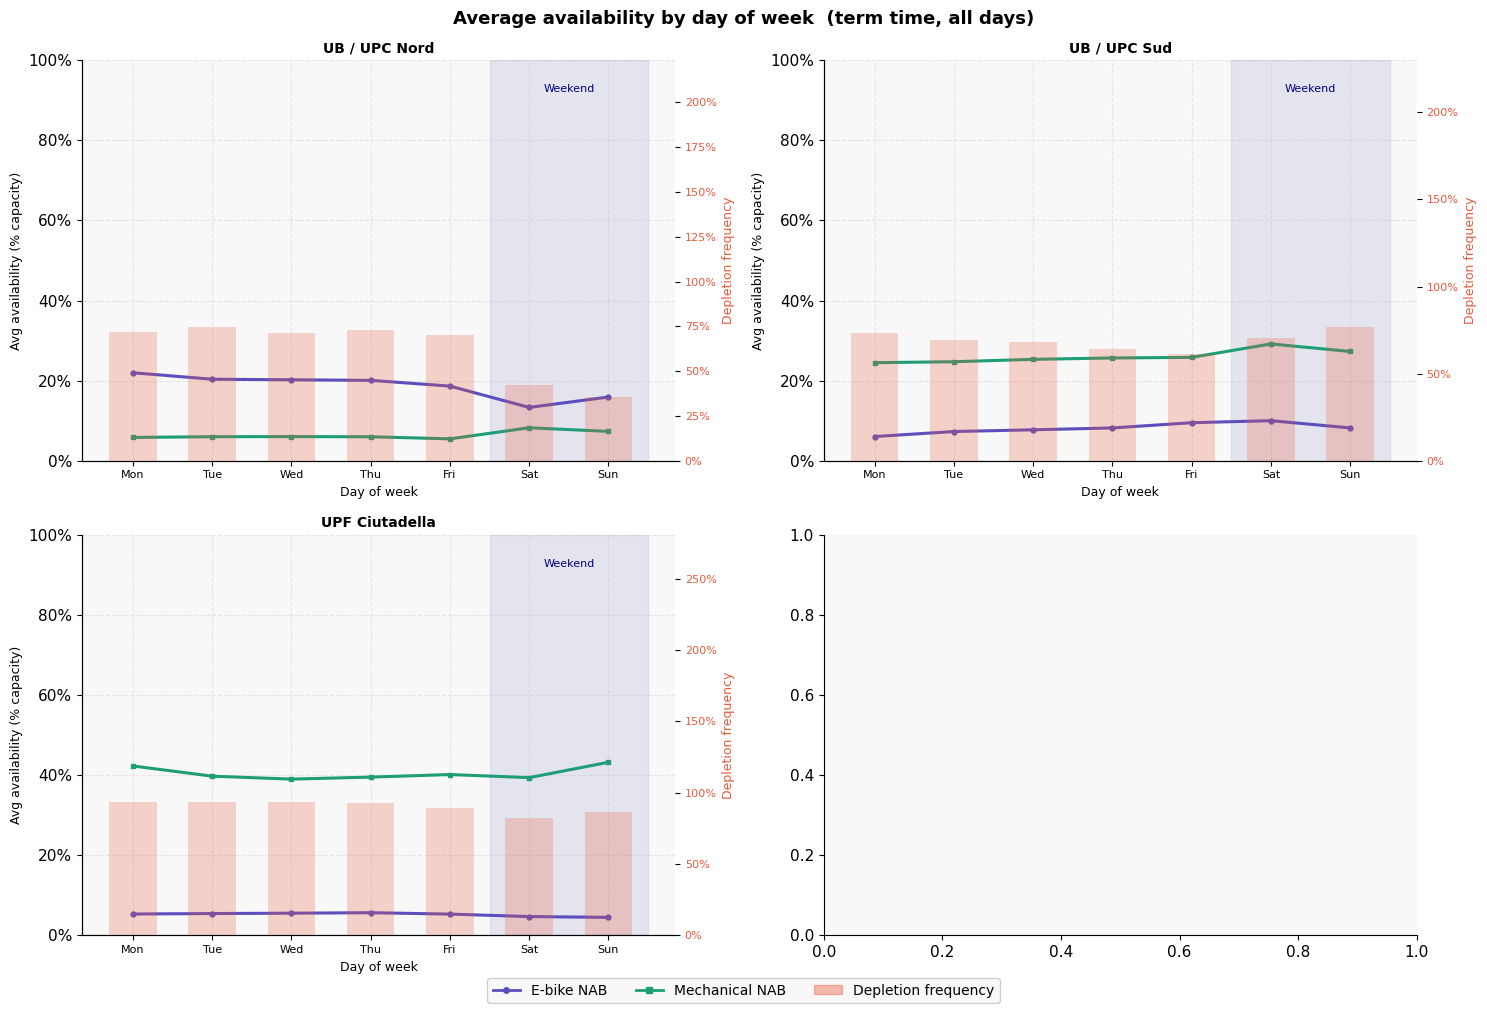

Saved: fig_temporal_dow.png


In [41]:
# ── Plot B: Day of week (all 7 days) ──────────────────────────────────────
# Uses ALL days (not just weekdays) so we can see the weekend contrast
DAY_LABELS = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(
    'Average availability by day of week  (term time, all days)',
    fontsize=13, fontweight='bold'
)

term_all = df[~df['month'].isin(SUMMER)].copy()

for ax, name in zip(axes.flat, CLUSTER_NAMES):
    grp = term_all[term_all['cluster'] == name]

    daily = grp.groupby('day_of_week').agg(
        ebike_NAB=('ebike_NAB', 'mean'),
        mech_NAB =('mech_NAB',  'mean'),
    ).reindex(range(7)).reset_index()

    depl_by_dow = (
        grp[grp['hour'].between(12, 20)]
        .groupby(['station_id', 'date_only', 'day_of_week'])['depleted']
        .first()
        .groupby('day_of_week').mean()
        .reindex(range(7), fill_value=0)
    )

    plot_availability_depletion(
        ax,
        x            = daily['day_of_week'],
        ebike_vals   = daily['ebike_NAB'],
        mech_vals    = daily['mech_NAB'],
        depl_vals    = depl_by_dow.values,
        xlabel       = 'Day of week',
        title        = name,
        xtick_labels = DAY_LABELS,
    )
    # Shade weekend
    ax.axvspan(4.5, 6.5, alpha=0.08, color='navy')
    ax.text(5.5, 0.92, 'Weekend', ha='center', fontsize=8, color='navy')

handles = [
    plt.Line2D([0],[0], color=C_EBIKE, lw=2, marker='o', ms=4, label='E-bike NAB'),
    plt.Line2D([0],[0], color=C_MECH,  lw=2, marker='s', ms=4, label='Mechanical NAB'),
    mpatches.Patch(color=C_DEPL, alpha=0.4, label='Depletion frequency'),
]
fig.legend(handles=handles, loc='lower center', ncol=3,
           fontsize=10, framealpha=0.9, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig('fig_temporal_dow.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_temporal_dow.png')

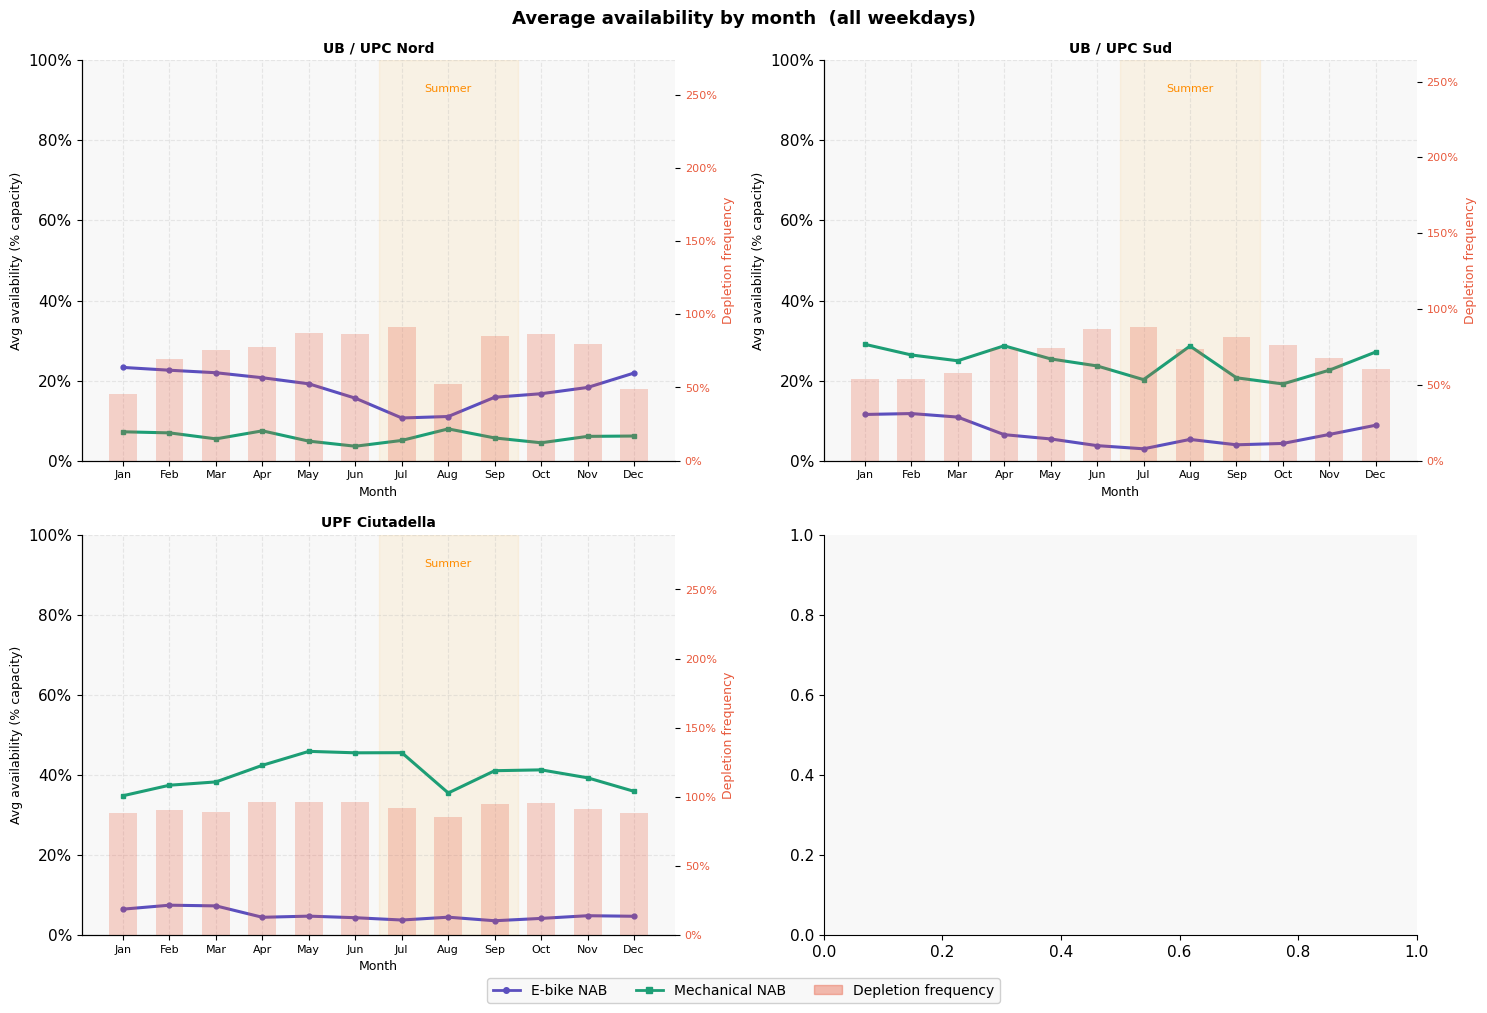

Saved: fig_temporal_monthly.png


In [42]:
# ── Plot C: Monthly pattern (seasonal / academic year view) ───────────────
MONTH_LABELS = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(
    'Average availability by month  (all weekdays)',
    fontsize=13, fontweight='bold'
)

wd_all = df[~df['is_weekend']].copy()

for ax, name in zip(axes.flat, CLUSTER_NAMES):
    grp = wd_all[wd_all['cluster'] == name]

    monthly = grp.groupby('month').agg(
        ebike_NAB=('ebike_NAB', 'mean'),
        mech_NAB =('mech_NAB',  'mean'),
    ).reindex(range(1, 13)).reset_index()

    depl_by_month = (
        grp[grp['hour'].between(12, 20)]
        .groupby(['station_id', 'date_only', 'month'])['depleted']
        .first()
        .groupby('month').mean()
        .reindex(range(1, 13), fill_value=0)
    )

    plot_availability_depletion(
        ax,
        x            = monthly['month'],
        ebike_vals   = monthly['ebike_NAB'],
        mech_vals    = monthly['mech_NAB'],
        depl_vals    = depl_by_month.values,
        xlabel       = 'Month',
        title        = name,
        xtick_labels = MONTH_LABELS,
    )
    # Shade summer
    ax.axvspan(6.5, 9.5, alpha=0.08, color='orange')
    ax.text(8, 0.92, 'Summer', ha='center', fontsize=8, color='darkorange')

handles = [
    plt.Line2D([0],[0], color=C_EBIKE, lw=2, marker='o', ms=4, label='E-bike NAB'),
    plt.Line2D([0],[0], color=C_MECH,  lw=2, marker='s', ms=4, label='Mechanical NAB'),
    mpatches.Patch(color=C_DEPL, alpha=0.4, label='Depletion frequency'),
]
fig.legend(handles=handles, loc='lower center', ncol=3,
           fontsize=10, framealpha=0.9, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig('fig_temporal_monthly.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_temporal_monthly.png')

### 3.6 — Weather analysis

We compare e-bike and mechanical availability — and depletion frequency — across three weather conditions:
- **Rainy vs dry** — using the `is_raining` column already in the data
- **Hot vs cool** — `temperature_2m > 25°C`
- **Windy vs calm** — using the `is_windy` column already in the data

All comparisons use term-time weekdays only.

In [43]:
# ── Weather condition slices ───────────────────────────────────────────────
CONDITIONS = {
    'Rainy'  : term_wd['is_raining'] == True,
    'Dry'    : term_wd['is_raining'] == False,
    'Hot'    : term_wd['temperature_2m'] > 25,
    'Cool'   : term_wd['temperature_2m'] <= 25,
    'Windy'  : term_wd['is_windy'] == True,
    'Calm'   : term_wd['is_windy'] == False,
}

# For each cluster and condition, compute mean ebike NAB, mech NAB,
# and depletion frequency during peak hours (12–20)
weather_rows = []
for cluster_name in CLUSTER_NAMES:
    cluster_mask = term_wd['cluster'] == cluster_name
    for cond_name, cond_mask in CONDITIONS.items():
        grp = term_wd[cluster_mask & cond_mask]
        if len(grp) == 0:
            continue
        depl_rate = (
            grp[grp['hour'].between(12, 20)]
            .groupby(['station_id', 'date_only'])['depleted']
            .first().mean()
        )
        weather_rows.append({
            'cluster'    : cluster_name,
            'condition'  : cond_name,
            'ebike_NAB'  : grp['ebike_NAB'].mean(),
            'mech_NAB'   : grp['mech_NAB'].mean(),
            'depl_rate'  : depl_rate,
            'n_hours'    : len(grp),
        })

weather_df = pd.DataFrame(weather_rows)
print('Weather summary computed:')
print(weather_df.to_string(index=False))

Weather summary computed:
       cluster condition  ebike_NAB  mech_NAB  depl_rate  n_hours
 UB / UPC Nord     Rainy   0.212697  0.068964   0.669196     5240
 UB / UPC Nord       Dry   0.201712  0.057829   0.724561    90033
 UB / UPC Nord       Hot   0.214201  0.026627   0.829457     3183
 UB / UPC Nord      Cool   0.201906  0.059541   0.720759    92090
 UB / UPC Nord     Windy   0.337974  0.070194   0.670455      601
 UB / UPC Nord      Calm   0.201455  0.058367   0.722777    94672
  UB / UPC Sud     Rainy   0.083202  0.286405   0.676185    14416
  UB / UPC Sud       Dry   0.077015  0.249733   0.672271   231616
  UB / UPC Sud       Hot   0.034396  0.147168   0.770508     8360
  UB / UPC Sud      Cool   0.078890  0.255565   0.669180   237672
  UB / UPC Sud     Windy   0.059160  0.299493   0.595436     1927
  UB / UPC Sud      Calm   0.077521  0.251506   0.672012   244105
UPF Ciutadella     Rainy   0.048513  0.388313   0.908467    10815
UPF Ciutadella       Dry   0.054439  0.401818   0.

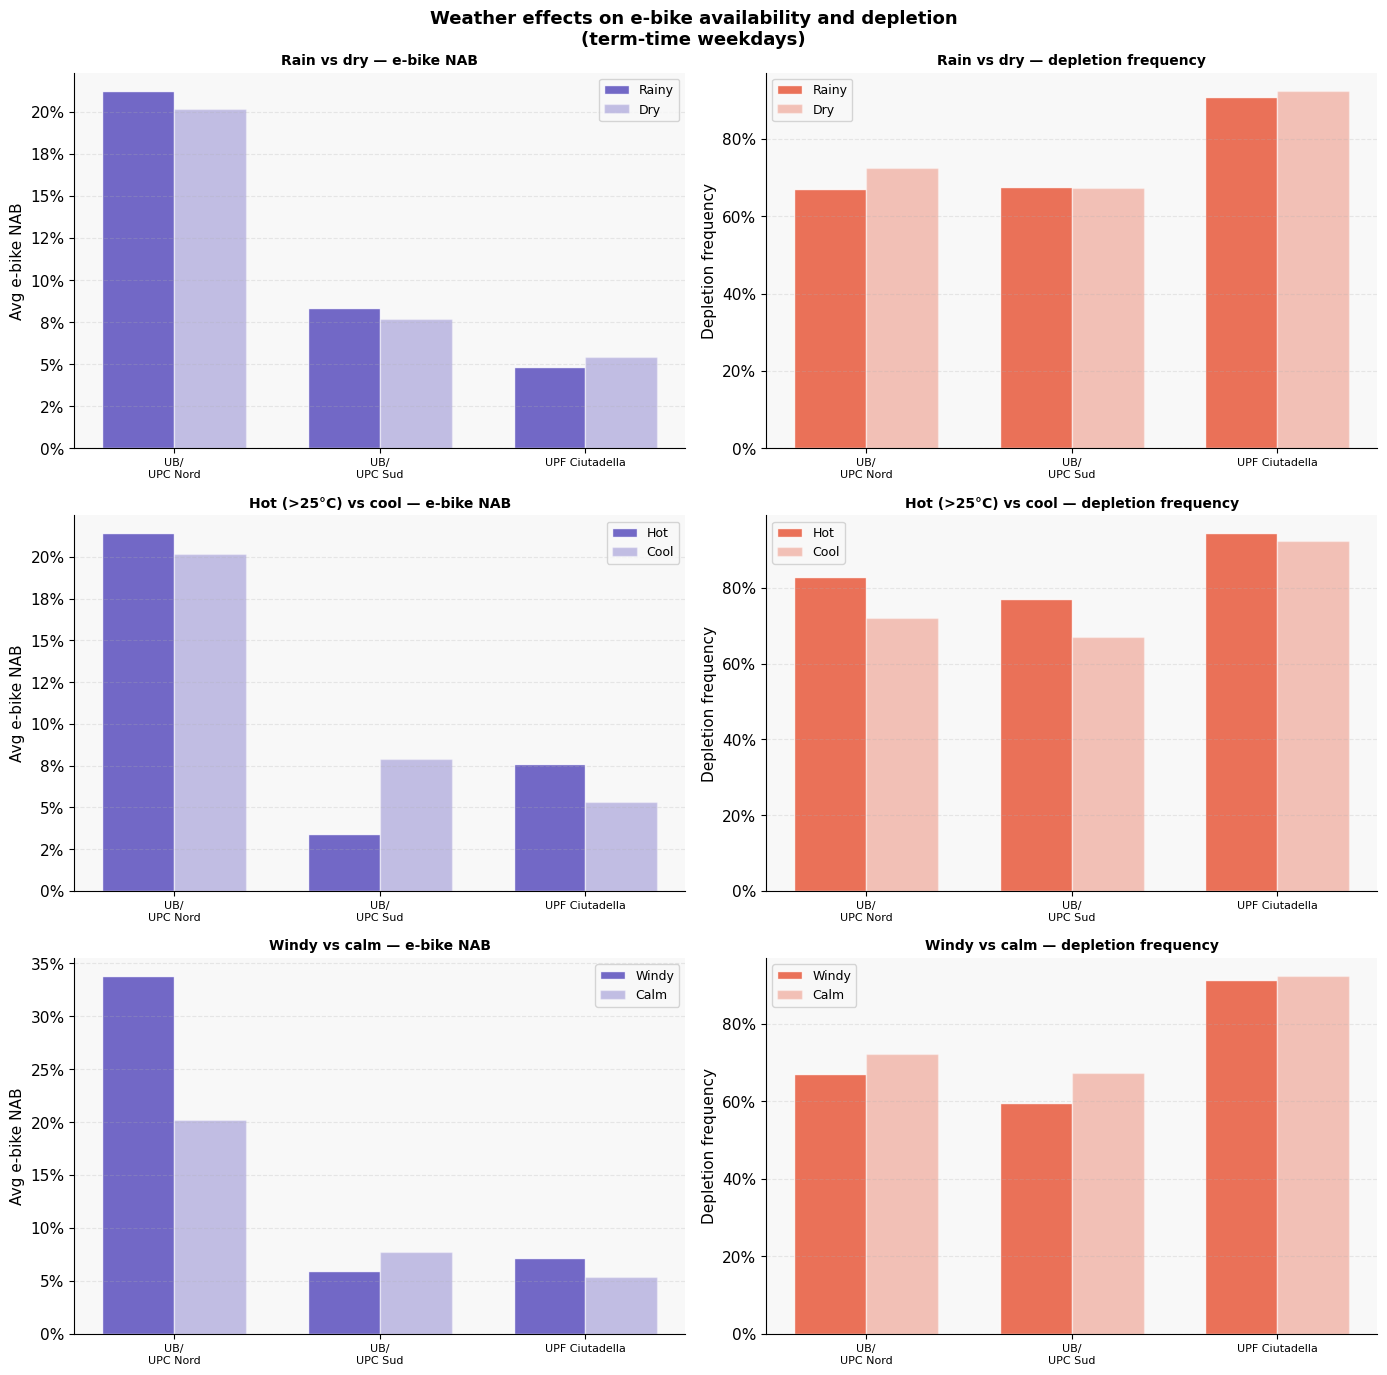

Saved: fig_weather_effects.png


In [44]:
# ── Plot D: Weather comparison — 3 paired conditions × 4 clusters ─────────
# Layout: 3 rows (rain, heat, wind) × 2 cols (NAB + depletion rate)

PAIRS = [
    ('Rainy',  'Dry',   'Rain vs dry'),
    ('Hot',    'Cool',  'Hot (>25°C) vs cool'),
    ('Windy',  'Calm',  'Windy vs calm'),
]

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
fig.suptitle(
    'Weather effects on e-bike availability and depletion\n'
    '(term-time weekdays)',
    fontsize=13, fontweight='bold'
)

x     = np.arange(len(CLUSTER_NAMES))
width = 0.35

for row_idx, (cond_a, cond_b, row_title) in enumerate(PAIRS):
    ax_nab  = axes[row_idx, 0]
    ax_depl = axes[row_idx, 1]

    vals_a_nab  = []
    vals_b_nab  = []
    vals_a_depl = []
    vals_b_depl = []

    for name in CLUSTER_NAMES:
        row_a = weather_df[(weather_df['cluster'] == name) &
                           (weather_df['condition'] == cond_a)]
        row_b = weather_df[(weather_df['cluster'] == name) &
                           (weather_df['condition'] == cond_b)]
        vals_a_nab.append(row_a['ebike_NAB'].values[0] if len(row_a) else 0)
        vals_b_nab.append(row_b['ebike_NAB'].values[0] if len(row_b) else 0)
        vals_a_depl.append(row_a['depl_rate'].values[0] if len(row_a) else 0)
        vals_b_depl.append(row_b['depl_rate'].values[0] if len(row_b) else 0)

    # NAB comparison
    ax_nab.bar(x - width/2, vals_a_nab, width, label=cond_a,
               color=C_EBIKE, alpha=0.85, edgecolor='white')
    ax_nab.bar(x + width/2, vals_b_nab, width, label=cond_b,
               color=C_EBIKE, alpha=0.35, edgecolor='white')
    ax_nab.set_title(f'{row_title} — e-bike NAB', fontsize=10, fontweight='bold')
    ax_nab.set_xticks(x)
    ax_nab.set_xticklabels(
        [n.replace(' / ', '/\n') for n in CLUSTER_NAMES], fontsize=8
    )
    ax_nab.set_ylabel('Avg e-bike NAB')
    ax_nab.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda v, _: f'{v:.0%}')
    )
    ax_nab.legend(fontsize=9)
    ax_nab.grid(True, alpha=0.25, axis='y', linestyle='--')
    ax_nab.spines['top'].set_visible(False)
    ax_nab.spines['right'].set_visible(False)

    # Depletion rate comparison
    ax_depl.bar(x - width/2, vals_a_depl, width, label=cond_a,
                color=C_DEPL, alpha=0.85, edgecolor='white')
    ax_depl.bar(x + width/2, vals_b_depl, width, label=cond_b,
                color=C_DEPL, alpha=0.35, edgecolor='white')
    ax_depl.set_title(f'{row_title} — depletion frequency', fontsize=10, fontweight='bold')
    ax_depl.set_xticks(x)
    ax_depl.set_xticklabels(
        [n.replace(' / ', '/\n') for n in CLUSTER_NAMES], fontsize=8
    )
    ax_depl.set_ylabel('Depletion frequency')
    ax_depl.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda v, _: f'{v:.0%}')
    )
    ax_depl.legend(fontsize=9)
    ax_depl.grid(True, alpha=0.25, axis='y', linestyle='--')
    ax_depl.spines['top'].set_visible(False)
    ax_depl.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig_weather_effects.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_weather_effects.png')

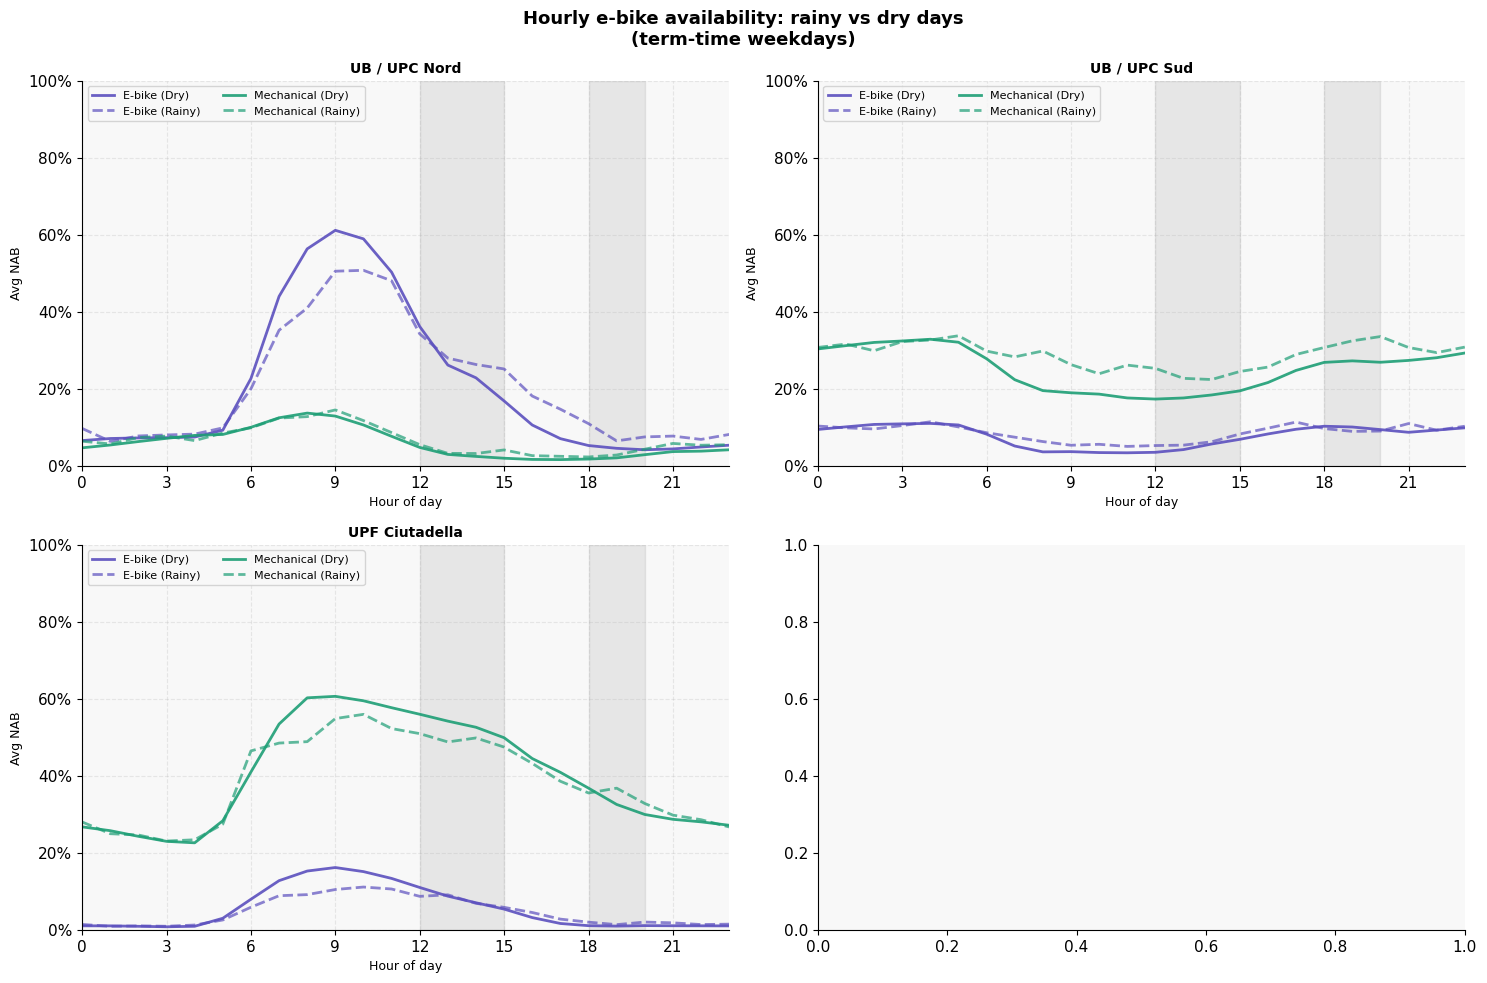

Saved: fig_weather_hourly_rain.png


In [45]:
# ── Plot E: Hourly profile on rainy vs dry days (for each cluster) ─────────
# Useful for seeing whether rain shifts *when* depletion happens,
# not just how often

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(
    'Hourly e-bike availability: rainy vs dry days\n'
    '(term-time weekdays)',
    fontsize=13, fontweight='bold'
)

for ax, name in zip(axes.flat, CLUSTER_NAMES):
    grp = term_wd[term_wd['cluster'] == name]

    for condition, mask, style, alpha in [
        ('Dry',   grp['is_raining'] == False, '-',  0.9),
        ('Rainy', grp['is_raining'] == True,  '--', 0.7),
    ]:
        h = grp[mask].groupby('hour')['ebike_NAB'].mean()
        ax.plot(h.index, h.values,
                color=C_EBIKE, lw=2, linestyle=style,
                alpha=alpha, label=f'E-bike ({condition})')

    for condition, mask, style, alpha in [
        ('Dry',   grp['is_raining'] == False, '-',  0.9),
        ('Rainy', grp['is_raining'] == True,  '--', 0.7),
    ]:
        h = grp[mask].groupby('hour')['mech_NAB'].mean()
        ax.plot(h.index, h.values,
                color=C_MECH, lw=2, linestyle=style,
                alpha=alpha, label=f'Mechanical ({condition})')

    ax.axvspan(12, 15, alpha=0.07, color='black')
    ax.axvspan(18, 20, alpha=0.07, color='black')
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_xlabel('Hour of day', fontsize=9)
    ax.set_ylabel('Avg NAB', fontsize=9)
    ax.set_xticks(range(0, 24, 3))
    ax.set_xlim(0, 23)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, alpha=0.25, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig_weather_hourly_rain.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_weather_hourly_rain.png')

In [49]:
# ── Mean altitude per cluster ──────────────────────────────────────────────
# Load station metadata from Step 1
metadata = pd.read_csv('station_metadata_2019-2024/2023_INFO.csv')

# Merge altitude onto cluster stations
cluster_alt = cluster_stations.merge(
    metadata[['station_id', 'altitude']].drop_duplicates('station_id'),
    on='station_id', how='left'
)

print('Mean altitude by cluster:')
alt_summary = (
    cluster_alt.groupby('cluster')['altitude']
    .agg(['mean', 'min', 'max', 'count'])
    .round(1)
    .rename(columns={'mean':'Avg altitude (m)', 'min':'Min', 'max':'Max', 'count':'Stations'})
    .sort_values('Avg altitude (m)', ascending=False)
)
print(alt_summary.to_string())

Mean altitude by cluster:
                Avg altitude (m)  Min  Max  Stations
cluster                                             
UB / UPC Nord               84.7   63  111         6
UB / UPC Sud                24.9   20   29        14
UPF Ciutadella               6.1    4    7        10


In [50]:
# For each cluster, look at the 6am snapshot (freshest stock before demand hits)
# and compute what fraction of capacity is e-bikes vs mechanical
morning_stock = df[df['hour'] == 6].groupby('cluster').agg(
    avg_ebikes_6am    = ('ebikes',     'mean'),
    avg_mechanical_6am= ('mechanical', 'mean'),
    avg_capacity      = ('capacity',   'mean'),
).round(2)

morning_stock['ebike_share_6am']  = (morning_stock['avg_ebikes_6am']     / morning_stock['avg_capacity'] * 100).round(1)
morning_stock['mech_share_6am']   = (morning_stock['avg_mechanical_6am'] / morning_stock['avg_capacity'] * 100).round(1)
morning_stock['total_fill_6am']   = ((morning_stock['avg_ebikes_6am'] + morning_stock['avg_mechanical_6am']) / morning_stock['avg_capacity'] * 100).round(1)

print('Morning stock (6am) by cluster:')
print(morning_stock[['avg_ebikes_6am','avg_mechanical_6am','avg_capacity',
                      'ebike_share_6am','mech_share_6am','total_fill_6am']].to_string())

Morning stock (6am) by cluster:
                avg_ebikes_6am  avg_mechanical_6am  avg_capacity  ebike_share_6am  mech_share_6am  total_fill_6am
cluster                                                                                                          
UB / UPC Nord             5.24                2.75         27.81             18.8             9.9            28.7
UB / UPC Sud              1.86                7.00         24.70              7.5            28.3            35.9
UPF Ciutadella            1.92               12.85         33.63              5.7            38.2            43.9


In [51]:
# ── UB/UPC Nord: e-bike depletion rate by hour ────────────────────────────
nord = df[
    (df['cluster'] == 'UB / UPC Nord') &
    (~df['is_weekend']) &
    (~df['month'].isin(SUMMER))
].copy()

# Depletion rate by hour: fraction of station-days where ebikes == 0 at that hour
depl_by_hour = (
    nord.groupby(['station_id', 'date_only', 'hour'])['ebikes']
    .first()
    .reset_index()
)
depl_by_hour['is_zero'] = (depl_by_hour['ebikes'] == 0).astype(int)

hourly_depl = (
    depl_by_hour.groupby('hour')['is_zero']
    .mean() * 100
).round(1)

# Also compute mean ebike NAB by hour for context
hourly_nab = nord.groupby('hour')['ebike_NAB'].mean() * 100

print('UB/UPC Nord — e-bike zero-availability rate by hour (term-time weekdays):')
print()
for h in range(24):
    bar_depl = '█' * int(hourly_depl.get(h, 0) / 5)
    print(f'  {h:02d}:00  zero: {hourly_depl.get(h,0):5.1f}%  NAB: {hourly_nab.get(h,0):4.1f}%  {bar_depl}')

UB/UPC Nord — e-bike zero-availability rate by hour (term-time weekdays):

  00:00  zero:  47.1%  NAB:  6.7%  █████████
  01:00  zero:  43.8%  NAB:  7.0%  ████████
  02:00  zero:  40.6%  NAB:  7.2%  ████████
  03:00  zero:  38.6%  NAB:  7.3%  ███████
  04:00  zero:  37.6%  NAB:  7.5%  ███████
  05:00  zero:  25.7%  NAB:  9.2%  █████
  06:00  zero:   9.1%  NAB: 22.5%  █
  07:00  zero:   2.1%  NAB: 43.4%  
  08:00  zero:   1.2%  NAB: 55.4%  
  09:00  zero:   0.8%  NAB: 60.5%  
  10:00  zero:   0.9%  NAB: 58.4%  
  11:00  zero:   2.2%  NAB: 50.1%  
  12:00  zero:   5.6%  NAB: 36.0%  █
  13:00  zero:   9.8%  NAB: 26.3%  █
  14:00  zero:  15.0%  NAB: 23.0%  ███
  15:00  zero:  28.4%  NAB: 17.1%  █████
  16:00  zero:  45.0%  NAB: 10.9%  █████████
  17:00  zero:  56.0%  NAB:  7.3%  ███████████
  18:00  zero:  62.8%  NAB:  5.5%  ████████████
  19:00  zero:  66.2%  NAB:  4.6%  █████████████
  20:00  zero:  65.4%  NAB:  4.2%  █████████████
  21:00  zero:  62.1%  NAB:  4.5%  ████████████
  22:00 

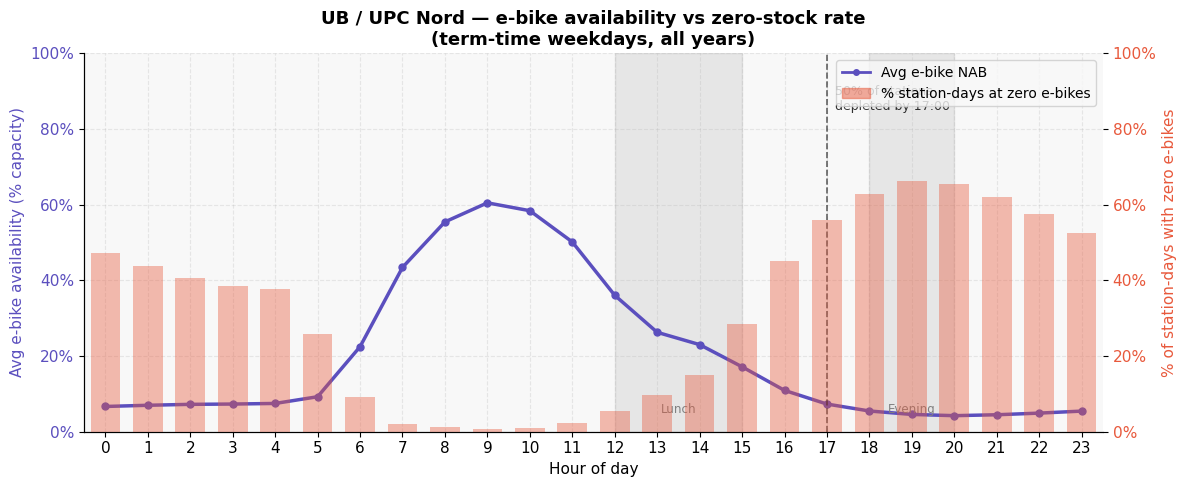

Saved: fig_nord_depletion_by_hour.png


In [52]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax2 = ax1.twinx()

# E-bike NAB line
ax1.plot(hourly_nab.index, hourly_nab.values,
         color=C_EBIKE, lw=2.5, marker='o', ms=5,
         label='E-bike NAB (% capacity)', zorder=3)
ax1.set_ylabel('Avg e-bike availability (% capacity)', color=C_EBIKE, fontsize=11)
ax1.tick_params(axis='y', labelcolor=C_EBIKE)
ax1.set_ylim(0, 100)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))

# Zero-availability bars
ax2.bar(hourly_depl.index, hourly_depl.values,
        color=C_DEPL, alpha=0.4, width=0.7, zorder=1,
        label='Hours at zero e-bikes (%)')
ax2.set_ylabel('% of station-days with zero e-bikes', color=C_DEPL, fontsize=11)
ax2.tick_params(axis='y', labelcolor=C_DEPL)
ax2.set_ylim(0, 100)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))

# Mark the point where depletion rate crosses 50%
crossover = hourly_depl[hourly_depl >= 50]
if len(crossover) > 0:
    first_cross = crossover.index[0]
    ax1.axvline(x=first_cross, color='black', lw=1.2,
                linestyle='--', alpha=0.6, zorder=4)
    ax1.text(first_cross + 0.2, 85,
             f'50% of stations\ndepleted by {first_cross:02d}:00',
             fontsize=9, color='black', alpha=0.8)

# Peak window shading
ax1.axvspan(12, 15, alpha=0.07, color='black')
ax1.axvspan(18, 20, alpha=0.07, color='black')
ax1.text(13.5, 5, 'Lunch', ha='center', fontsize=8.5, color='gray')
ax1.text(19.0, 5, 'Evening', ha='center', fontsize=8.5, color='gray')

ax1.set_xlabel('Hour of day', fontsize=11)
ax1.set_xticks(range(0, 24))
ax1.set_xlim(-0.5, 23.5)
ax1.set_title(
    'UB / UPC Nord — e-bike availability vs zero-stock rate\n'
    '(term-time weekdays, all years)',
    fontsize=13, fontweight='bold'
)
ax1.grid(True, alpha=0.25, linestyle='--', zorder=0)
ax1.spines['top'].set_visible(False)

handles = [
    plt.Line2D([0],[0], color=C_EBIKE, lw=2, marker='o', ms=4,
               label='Avg e-bike NAB'),
    mpatches.Patch(color=C_DEPL, alpha=0.5,
                   label='% station-days at zero e-bikes'),
]
ax1.legend(handles=handles, fontsize=10, loc='upper right')

plt.tight_layout()
plt.savefig('fig_nord_depletion_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_nord_depletion_by_hour.png')